# Low-density parity-check Code
## Density Evolution

In [1]:
import numpy as np
from scipy.stats import poisson

In [17]:
def DE_LDPC(d_l, d_r, num_iterations=60):
    delta_list = np.linspace(0.01, 0.1, 1000) 
    threshold = 0

    for delta in delta_list:

        X = 1  
        for _ in range(num_iterations):
            X = (1 - (1 - X) ** (d_r-1)) ** (d_l-1) * delta
        if X < 1e-6: threshold = delta

    print(f"Threshold for LDPC ({d_l}, {d_r}) is about {threshold:.5f}")
    print(f"Code rate: {1-d_l/d_r}, overhear: {(1/(1-d_l/d_r)-1)*100:.5f}%")

In [19]:
# Parameters
d_l = 5
d_r = 80
DE_LDPC(d_l, d_r)

Threshold for LDPC (5, 80) is about 0.04360
Code rate: 0.9375, overhear: 6.66667%


In [20]:
d_l = 4
d_r = 40
DE_LDPC(d_l, d_r)

Threshold for LDPC (4, 40) is about 0.07694
Code rate: 0.9, overhear: 11.11111%


## Monolithic LDPC code

In [4]:
import matplotlib.pyplot as plt

In [ ]:
def generate_regular_ldpc(n_var=3000, d_v=4, d_c=40):
    """
    Generate a regular (d_v, d_c) LDPC matrix H.
    @param(n_var): number of variable nodes
    @param(d_v): degree of each variable node
    @param(d_c): degree of each check node

    @return: np.ndarray
    """
    n_check = n_var * d_v // d_c
    assert n_check * d_c == n_var * d_v, "d_v * n_var must be divisible by d_c"
    H = np.zeros((n_check, n_var), dtype=int)

    var_indices = np.repeat(np.arange(n_var), d_v)
    check_indices = np.repeat(np.arange(n_check), d_c)
    
    np.random.shuffle(check_indices)
    used_pairs = set()
    
    for c, v in zip(check_indices, var_indices):
        while (c, v) in used_pairs:
            c = np.random.choice(check_indices)
        H[c, v] += 1
        used_pairs.add((c, v))
        assert H[c, v] <= 1
    
    return H


In [6]:
generate_regular_ldpc()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]], shape=(300, 3000))

In [7]:

def bec_channel(x, erasure_prob=0.1):
    received = x.copy()
    erasures = np.random.rand(len(x)) < erasure_prob
    received[erasures] = -1  
    return received


In [8]:
def peeling_decoder(H, received):
    n_check, n_var = H.shape
    decoded = received.copy()

    while True:
        progress = False
        for i in range(n_check):
            idxs = np.where(H[i, :] == 1)[0]
            known = idxs[decoded[idxs] != -1]
            unknown = idxs[decoded[idxs] == -1]
            if len(unknown) == 1:
                j = unknown[0]
                parity = np.sum(decoded[known]) % 2
                decoded[j] = parity
                progress = True
        if not progress:
            break
    return decoded

In [11]:
def run_experiment(n, d_v, d_c, start=0.01, end=0.1):
    num_trials = 1000
    epsilons = np.linspace(start, end, 10)  

    success_rates = []

    np.random.seed(42)
    H = generate_regular_ldpc(n_var=n, d_v=d_v, d_c=d_c)

    for eps in epsilons:
        success_count = 0
        for _ in range(num_trials):
            codeword = np.zeros(n, dtype=int)  
            received = bec_channel(codeword, eps)
            decoded = peeling_decoder(H, received)
            if -1 not in decoded and np.all(np.mod(H @ decoded, 2) == 0):
                success_count += 1
        success_rate = success_count / num_trials
        success_rates.append(success_rate)
        print(f"Epsilon={eps:.3f}, Success Rate={success_rate:.3f}")

    plt.plot(epsilons, success_rates, marker='o')
    plt.xlabel('Erasure Probability (epsilon)')
    plt.ylabel('Success Rate')
    plt.title(f'(dv={d_v}, dc={d_c}) LDPC over BEC')
    plt.grid(True)
    plt.show()

Epsilon=0.010, Success Rate=0.989
Epsilon=0.020, Success Rate=0.957
Epsilon=0.030, Success Rate=0.921
Epsilon=0.040, Success Rate=0.854
Epsilon=0.050, Success Rate=0.754
Epsilon=0.060, Success Rate=0.647
Epsilon=0.070, Success Rate=0.519
Epsilon=0.080, Success Rate=0.393
Epsilon=0.090, Success Rate=0.303
Epsilon=0.100, Success Rate=0.174


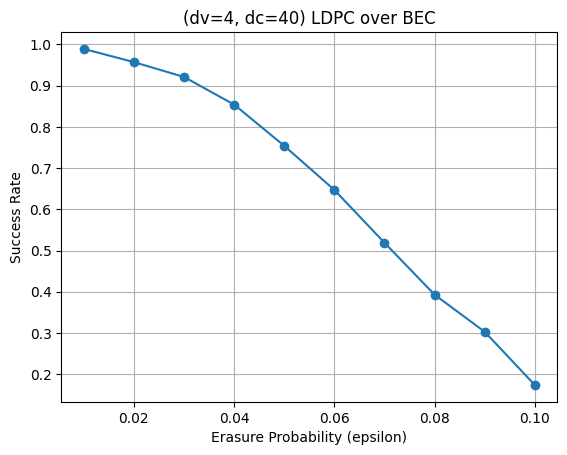

In [12]:
np.random.seed(42)
n = 100; d_v = 4; d_c = 40
start, end = 0.01, 0.1
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=0.984
Epsilon=0.020, Success Rate=0.968
Epsilon=0.030, Success Rate=0.963
Epsilon=0.040, Success Rate=0.903
Epsilon=0.050, Success Rate=0.816
Epsilon=0.060, Success Rate=0.687
Epsilon=0.070, Success Rate=0.502
Epsilon=0.080, Success Rate=0.320
Epsilon=0.090, Success Rate=0.215
Epsilon=0.100, Success Rate=0.111


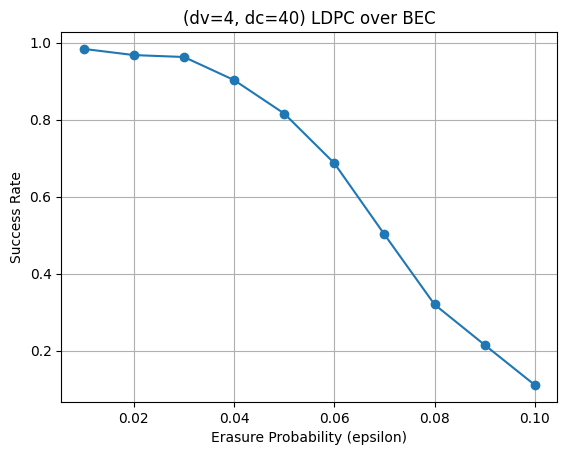

In [13]:
n = 200; d_v = 4; d_c = 40
start, end = 0.01, 0.1
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=1.000
Epsilon=0.020, Success Rate=1.000
Epsilon=0.030, Success Rate=1.000
Epsilon=0.040, Success Rate=0.996
Epsilon=0.050, Success Rate=0.975
Epsilon=0.060, Success Rate=0.869
Epsilon=0.070, Success Rate=0.615
Epsilon=0.080, Success Rate=0.320
Epsilon=0.090, Success Rate=0.097
Epsilon=0.100, Success Rate=0.033


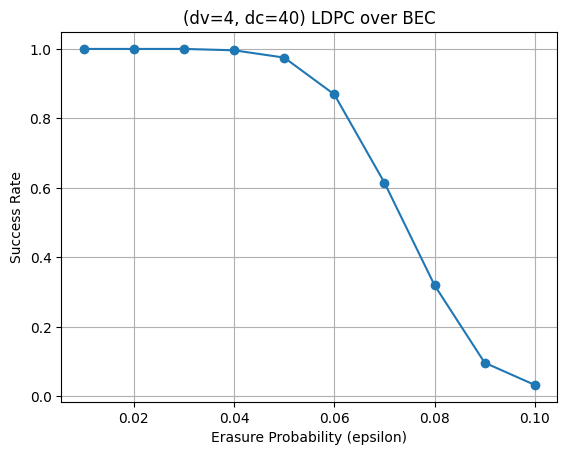

In [14]:
n = 500; d_v = 4; d_c = 40
start, end = 0.01, 0.1
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=1.000
Epsilon=0.020, Success Rate=1.000
Epsilon=0.030, Success Rate=1.000
Epsilon=0.040, Success Rate=0.999
Epsilon=0.050, Success Rate=0.999
Epsilon=0.060, Success Rate=0.963
Epsilon=0.070, Success Rate=0.708
Epsilon=0.080, Success Rate=0.313
Epsilon=0.090, Success Rate=0.055
Epsilon=0.100, Success Rate=0.004


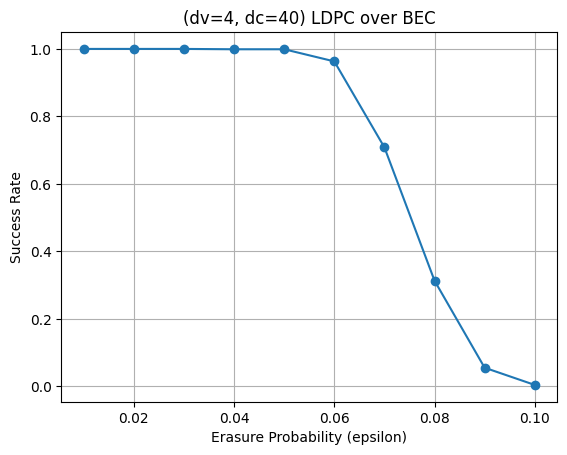

In [15]:
n = 1000; d_v = 4; d_c = 40
start, end = 0.01, 0.1
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=1.000
Epsilon=0.020, Success Rate=1.000
Epsilon=0.030, Success Rate=1.000
Epsilon=0.040, Success Rate=1.000
Epsilon=0.050, Success Rate=1.000
Epsilon=0.060, Success Rate=0.998
Epsilon=0.070, Success Rate=0.820
Epsilon=0.080, Success Rate=0.262
Epsilon=0.090, Success Rate=0.022
Epsilon=0.100, Success Rate=0.000


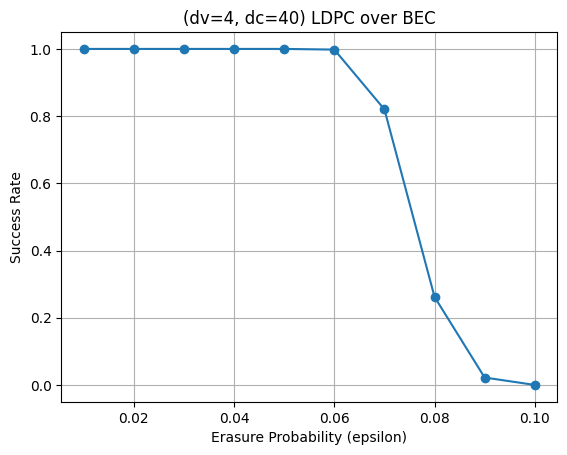

In [16]:
n = 2000; d_v = 4; d_c = 40
start, end = 0.01, 0.1
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.060, Success Rate=1.000
Epsilon=0.064, Success Rate=1.000
Epsilon=0.069, Success Rate=0.960
Epsilon=0.073, Success Rate=0.788
Epsilon=0.078, Success Rate=0.382
Epsilon=0.082, Success Rate=0.071
Epsilon=0.087, Success Rate=0.006
Epsilon=0.091, Success Rate=0.000
Epsilon=0.096, Success Rate=0.000
Epsilon=0.100, Success Rate=0.000


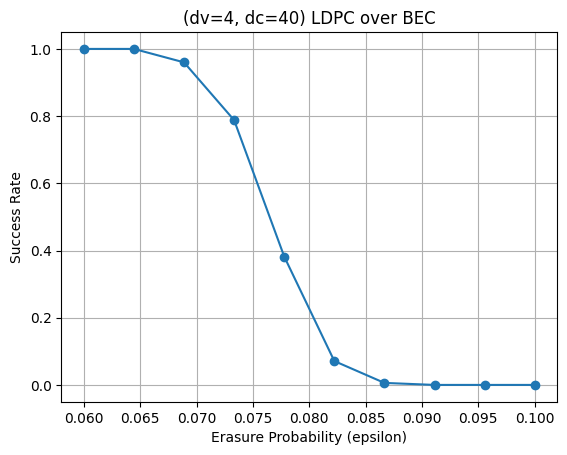

In [22]:
n = 5000; d_v = 4; d_c = 40
start, end = 0.06, 0.1
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=1.000
Epsilon=0.020, Success Rate=1.000
Epsilon=0.030, Success Rate=1.000
Epsilon=0.040, Success Rate=1.000
Epsilon=0.050, Success Rate=1.000
Epsilon=0.060, Success Rate=1.000
Epsilon=0.070, Success Rate=0.983
Epsilon=0.080, Success Rate=0.131
Epsilon=0.090, Success Rate=0.000
Epsilon=0.100, Success Rate=0.000


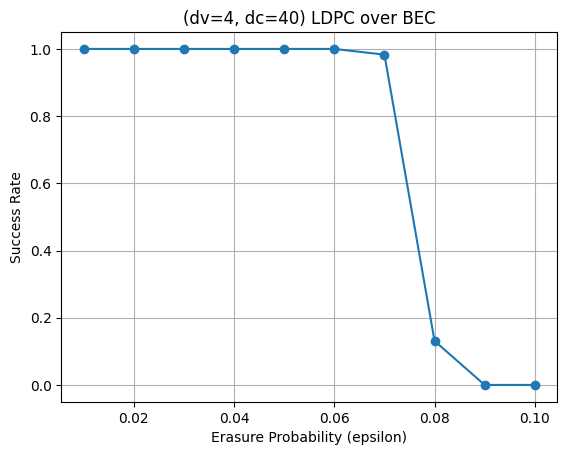

In [23]:
n = 10000; d_v = 4; d_c = 40
start, end = 0.01, 0.1
run_experiment(n, d_v, d_c, start=start, end=end)